In [ ]:
    import igraph as ig
    import networkx as nx
    import os
    import pickle

    for path in sorted(os.listdir('./FINDER')):
        file_name = os.path.basename(path)
        print(file_name)
        g_name = file_name.split('.')[0]
        g_type = file_name.split('.')[-1]
        if g_type == 'txt':
            g = ig.Graph.from_networkx(nx.read_edgelist(path,nodetype=int))
            with open(f'{g_name}.pkl', 'wb') as out_f:
                pickle.dump(g, out_f)
    

Crime.pkl
Digg.pkl
Enron.pkl
Epinions.pkl
Facebook.pkl
Gnutella31.txt
HI-II-14.txt
change.ipynb


In [235]:
import os
import pickle
import igraph as ig
graph_dir = './train/200_300_ER_LPA_COPY_SBM_LBR'

net_dict = {}
for net_no,path in enumerate(sorted(os.listdir(graph_dir))):
    with open(os.path.join(graph_dir,path), 'rb') as f:
        g_dict = pickle.load(f)
        net_dict[net_no] = g_dict 
    # print(g)
    # ig.summary(g)
save_name = f"{os.path.basename(graph_dir)}.pkl"
with open(save_name,'wb') as f:
    pickle.dump(net_dict,f)

In [1]:
import igraph as ig
import pickle

g = ig.Graph.Erdos_Renyi(100,0.4)
with open('test/simple_100.pkl', 'wb') as out_f:
    pickle.dump(g, out_f)

## visualize graphs

In [158]:
def statistics(g):
    leiden_comm = g.community_leiden(
        objective_function="modularity", 
        weights=None, 
        resolution_parameter=1.0, 
        n_iterations=2
    )

    if g.is_connected():
        df = pd.DataFrame(columns=['AvgDegree', 'Diam', 'AvgShortPath','Clustering Coffe','r','Q'])
        AD = np.mean(g.degree())
        CC = g.transitivity_avglocal_undirected() 
        Diam = g.diameter()
        AvgShortPath = g.average_path_length()
        r = g.assortativity_degree()
        Q = leiden_comm.modularity
        df.loc[len(df)] = [AD, Diam, AvgShortPath,CC, r,Q]
        print(df)
    else: 
        print("unconnected graph")
        df = pd.DataFrame(columns=['AvgDegree','Clustering Coffe','r','Q'])
        AD = np.mean(g.degree())
        CC = g.transitivity_avglocal_undirected() 
        r = g.assortativity_degree()
        Q = leiden_comm.modularity
        df.loc[len(df)] = [AD,CC, r,Q]
        print(df)

pref_matrix = [[0.3, 0.01], [0.01, 0.3]]
g = ig.Graph.SBM(n=100, pref_matrix=pref_matrix, block_sizes=[50, 50])
statistics(g)

   AvgDegree  Diam  AvgShortPath  Clustering Coffe        r         Q
0      14.94   4.0       2.28404          0.280287 -0.02728  0.473182


generated 2000 graphs
Processing 1/2000
Processing 1001/2000

Creating scatter plot with 2000 points...


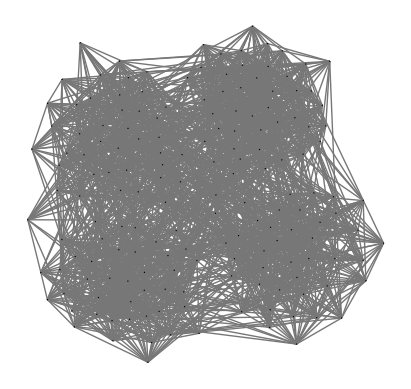

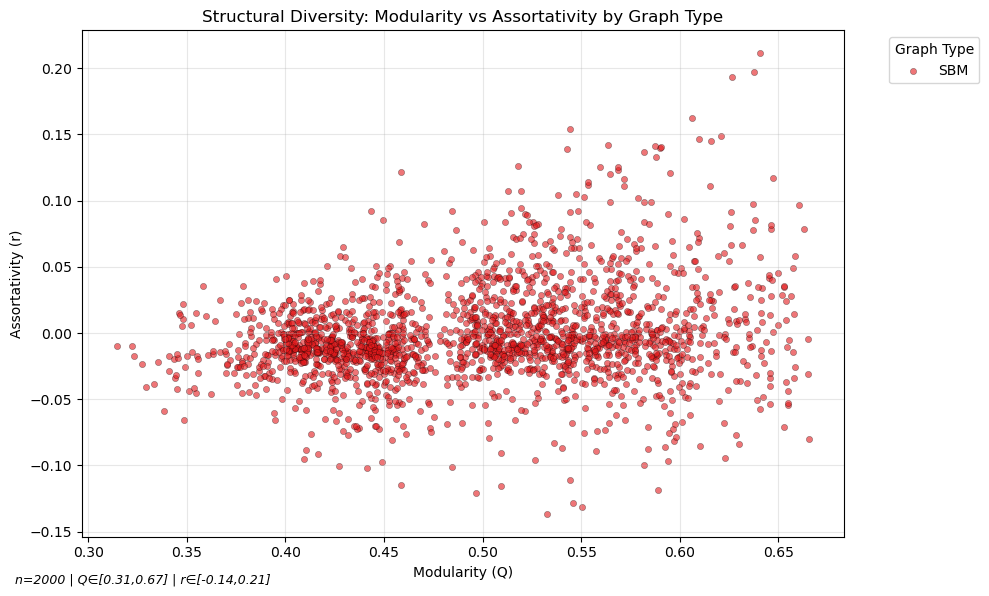

In [ ]:
import igraph as ig
import numpy as np
import sys
import pandas as pd
import os
import importlib
import graph_models
import structural_diversity_analysis
importlib.reload(graph_models)
importlib.reload(structural_diversity_analysis)
sys.path.append(r"O:\My_Codes\GD2026\MIND-ND\utils")
from plot import plot_graph
from graph_models import copying_model,LPA,stochastic_block_model,random_geometric_graph,random_regular_graph,watts_strogatz_model
from graph_models import _ring_based_regular
from graph_models import *
from structural_diversity_analysis import calculate_properties,create_scatter_plot

# topology = np.random.choice(['LPA', 'Copy', 'ER', 'SBM', 'DC-SBM', 'RGG'])
def generate(num = 2000,is_rewiring=False):
    graphs = []
    n_min = 100
    n_max = 200
    n = 0
    while n < num:
        topology = 'SBM'
        N = np.random.randint(n_min,n_max+1)
        m = np.random.choice([1, 2, 3, 4, 5, 6, 8, 10],
                                p=[1/12, 2/12, 2/12, 2/12, 2/12, 1/12, 1/12, 1/12])
        
        if topology == 'Ring':
            g = ig.Graph.Ring(N, directed=False)
        elif topology == '2D-lattice':
            g = ig.Graph.Lattice([5, 5], nei=1, directed=False, mutual=False, circular=False)
        elif topology == 'Regular':
            g = random_regular_graph(N,k=m)
            # g = _ring_based_regular(N,k=m)
        elif topology == 'WS':
            g = watts_strogatz_model(N,k=m,p=0.2)
        elif topology == 'ER':
            g = ig.Graph.Erdos_Renyi(n=N, p=((N - 1) * m - 1) / (N * (N - 1)))
        elif topology == 'BA':
            g = ig.Graph.Barabasi(N, m, directed=False)
        elif topology == 'Copy':
            gamma = 2.5 + np.random.rand()
            g = copying_model(N, m, gamma)
        elif topology == 'LPA':
            gamma = 2.5 + np.random.rand()
            g = LPA(N, m, gamma)
        elif topology == 'SBM':
            # pref_matrix = [[0.3, 0.01], [0.01, 0.3]]
            # g = ig.Graph.SBM(n=100, pref_matrix=pref_matrix, block_sizes=[50, 50])
            ratio = 5 * np.random.uniform(1,6) # 5-10x
            p_out = max(0.01,np.random.rand() / 10)
            p_in = min(ratio*p_out,0.9)
            num_blocks = np.random.randint(2, 5)
            g = stochastic_block_model(N,p_in,p_out,num_blocks)
            
        elif topology == 'RGG':
            r = np.sqrt(np.log(N) / (np.pi * N))
            r = np.random.uniform(1.1,2.0) * r
            g = random_geometric_graph(N, r)
        else:
            raise Exception('Topology not valid!!')

        if g.is_connected():
            g = g  # Already connected, no need to extract
        else:
            g = g.subgraph(max(g.connected_components(), key=len)) 
        
        switch_type = np.random.randint(3) - 1 #[-1,0,1]
        r_coeff = 0.05 if switch_type == 0 \
                else switch_type * np.random.choice([0.15, 0.2, 0.25, 0.3, 0.4, 0.5])
        if topology in ['LPA','Copy']:
            if m==1:
                r_coeff = 0.01 + 0.04 * np.random.rand() if switch_type == 0 else \
                                    switch_type * np.random.choice([0.05, 0.1, 0.15])
        # print("r_target: ",r_coeff," switch_type: ",switch_type)
        
        if is_rewiring:
            g, node_order, ordering, switch_count = rewiring(g,switch_type,r_coeff)
            if g.is_connected():
                g = g  # Already connected, no need to extract
            else:
                g = g.subgraph(max(g.connected_components(), key=len)) 
        
        if g.is_connected and g.vcount() >= n_min and g.vcount() <= n_max:
            graphs.append((g, topology))
            n += 1
   
    return graphs

graphs = generate(2000,is_rewiring=False)
print(f"generated {len(graphs)} graphs")
plot_graph(graphs[0][0])
q_values, r_values, labels = calculate_properties(graphs)
# Visualize and summarize
create_scatter_plot(q_values, r_values, labels)

# target_k = np.random.randint(2, 10)
# # Randomly choose to increase or decrease community structure
# mode = 'increase' if np.random.rand() > 0.2 else 'decrease'
# net = community_aware_rewiring(g, K=target_k, iterations=N*5, mode=mode)
# print("target_k: ",target_k," mode: ",mode)
# if g.is_connected():
#     g = g  # Already connected, no need to extract
# else:
#     g = g.subgraph(max(g.connected_components(), key=len)) 
# plot_graph(g)
# statistics(g)




In [32]:
 np.random.uniform(1,6) 

4.004078550605099

In [39]:
save_dir = "valid"

for p in os.listdir(save_dir):
    if "SBM" in p:
        os.remove(os.path.join(save_dir,p))

KeyboardInterrupt: 

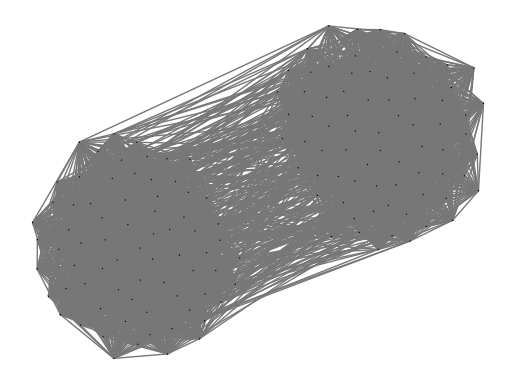

In [40]:
sys.path.append(r"O:\My_Codes\GD2026\MIND-ND\utils")
from plot import plot_graph
plot_graph(graphs[5][0])
save_dir = "valid"
net_dict = {}
exist_no = len(os.listdir(save_dir))
for net_no, (g, topology) in enumerate(graphs):
    net_dict[net_no] = {'adj': np.array(g.get_adjacency().data, dtype=bool)}
    net_dict[net_no]['info'] = {
        'topology': 'SBM',
        'size': g.vcount(),
        'mean_deg': np.mean(g.degree()),
        'assortativity': g.assortativity_degree()
    }
             
    with open(os.path.join(save_dir,f"{net_no+exist_no:05d}_SBM.pkl"),'wb') as f:
        pickle.dump(g,f)


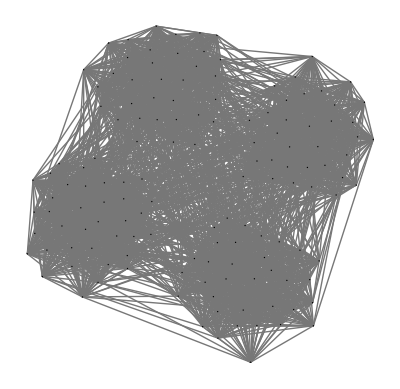

In [ ]:
sys.path.append(r"O:\My_Codes\GD2026\MIND-ND\utils")
from plot import plot_graph
plot_graph(graphs[5][0])
save_dir = "train/100_200_SBM_2000"
net_dict = {}
for net_no, (g, topology) in enumerate(graphs):
    net_dict[net_no] = {'adj': np.array(g.get_adjacency().data, dtype=bool)}
    net_dict[net_no]['info'] = {
        'topology': 'SBM',
        'size': g.vcount(),
        'mean_deg': np.mean(g.degree()),
        'assortativity': g.assortativity_degree()
    }
             
    with open(os.path.join(save_dir,f"{net_no:05d}.pkl"),'wb') as f:
        pickle.dump(g,f)

with open('100_200_SBM_2000.pkl', 'wb') as out_f:
    pickle.dump(net_dict, out_f)

## real dataset analyze

In [ ]:
sys.path.append(r"O:\My_Codes\GD2026\MIND-ND\utils")
from common import load_g
# # data_path = "real/FINDER/Gnutella31.pkl"
data_path = "real/social/soc-Epinions1.pkl"
g = load_g(data_path,name='test') 
statistics(g)

In [21]:
import igraph as ig
sys.path.append(r"O:\My_Codes\GD2026\MIND-ND\utils")
from common import load_g
data_path = "real/FINDER/Crime.pkl"
 
g = load_g(data_path,name='test') 
# g.transitivity_avglocal_undirected()  
g.transitivity_undirected()

import networkx as nx
def ig_to_nx(ig_graph):
    edges = ig_graph.get_edgelist()
    G = nx.Graph()
    G.add_edges_from(edges)
    return G
g_nx = ig_to_nx(g)
nx.average_clustering(g_nx)         #  By default includes all nodes,count_zeros=True
g.transitivity_avglocal_undirected()    # excludes nodes with degree < 2 from the average

0.11249299521131778

## comprehensive dataset analysis

In [18]:
import pickle

# Load all dictionaries
dicts = []
filenames = ['switched_graphs_1218.pkl', 'switched_graphs_1218_2.pkl', '100_200_ER_LPA_COPY_10000.pkl']

for filename in filenames:
    with open(filename, 'rb') as f:
        dicts.append(pickle.load(f))

# Combine with sequential keys
combined_net_dict = {}
current_key = 0

for net_dict in dicts:
    for value in net_dict.values():
        combined_net_dict[current_key] = value
        current_key += 1

# Save combined dictionary
with open('combined_graphs.pkl', 'wb') as f:
    pickle.dump(combined_net_dict, f)

print(f"Combined {sum(len(d) for d in dicts)} graphs into {len(combined_net_dict)} entries")


Combined 6603 graphs into 6603 entries


In [17]:
import pickle
with open('switched_graphs_1218.pkl', 'rb') as f:
    net_dict_1 = pickle.load(f)
    print(type(net_dict_1))
    print(len(net_dict_1))
    print(net_dict_1[0])

with open('switched_graphs_1218_2.pkl', 'rb') as f:
    net_dict_2 = pickle.load(f)
    print(len(net_dict_2))
    print(net_dict_2[0])

with open('100_200_ER_LPA_COPY_10000.pkl', 'rb') as f:
    net_dict_3 = pickle.load(f)
    print(len(net_dict_3))
    print(net_dict_3[0])

<class 'dict'>
1001
{'adj': array([[False,  True,  True, ..., False, False, False],
       [ True, False,  True, ..., False, False, False],
       [ True,  True, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]]), 'info': {'topology': 'LPA', 'size': 186, 'mean_deg': 3.967741935483871, 'assortativity': 0.011025683014731644, 'ordering': 'rnd', 'switch_count': 1, 'gamma': 3.2582142054701793}}
701
{'adj': array([[False,  True,  True, ..., False, False, False],
       [ True, False,  True, ..., False, False, False],
       [ True,  True, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]]), 'info': {'topology': 'LPA', 'size': 153, 'mean_deg': 3.9607843137254903, 'assorta